<a href="https://colab.research.google.com/github/kalyani-n2711/PCOS-Ultrasound-Analysis/blob/main/Copy_of_main06jan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel('/content/polycystic-ovary-syndrome-pcosnew.xlsx')

In [ ]:
df['AMH(ng/mL)'] = pd.to_numeric(df['AMH(ng/mL)'], errors='coerce')
df['Unnamed: 42']=pd.to_numeric(df['Unnamed: 42'], errors='coerce')

In [ ]:
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 42
0,1,10001,0,28.0,44.6,152.0,19.300000,15.0,78.0,22.0,...,1.0,0,NaN,80.0,3.0,3.0,18.0,18.0,8.5,NaN
1,2,10002,0,36.0,65.0,161.5,24.921163,NaN,74.0,20.0,...,0.0,0,120.0,70.0,3.0,5.0,15.0,14.0,3.7,NaN
2,3,10003,1,33.0,68.8,165.0,25.270891,11.0,72.0,18.0,...,1.0,0,120.0,80.0,13.0,15.0,NaN,20.0,10.0,NaN
3,4,10004,0,NaN,65.0,148.0,29.674945,13.0,72.0,20.0,...,0.0,0,120.0,70.0,2.0,2.0,15.0,14.0,7.5,NaN
4,5,10005,0,25.0,52.0,161.0,20.060954,11.0,72.0,18.0,...,0.0,0,120.0,NaN,NaN,4.0,16.0,14.0,7.0,NaN


In [ ]:
!pip install sweetviz
import sweetviz as sv

report = sv.analyze(df)
report.show_html("report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sl. No                 541 non-null    int64  
 1   Patient File No.       541 non-null    int64  
 2   PCOS (Y/N)             541 non-null    int64  
 3   Age (yrs)              532 non-null    float64
 4   Weight (Kg)            533 non-null    float64
 5   Height(Cm)             533 non-null    float64
 6   BMI                    535 non-null    float64
 7   Blood Group            534 non-null    float64
 8   Pulse rate(bpm)        537 non-null    float64
 9   RR (breaths/min)       536 non-null    float64
 10  Hb(g/dl)               534 non-null    float64
 11  Cycle(R/I)             541 non-null    int64  
 12  Cycle length(days)     541 non-null    int64  
 13  Marraige Status (Yrs)  540 non-null    float64
 14  Pregnant(Y/N)          541 non-null    int64  
 15  No. of

In [ ]:
#trimming column names where there are extra spaces at start and end
df = df.rename(columns=lambda x: x.strip())
df.head(2)

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 42
0,1,10001,0,28.0,44.6,152.0,19.300000,15.0,78.0,22.0,...,1.0,0,NaN,80.0,3.0,3.0,18.0,18.0,8.5,NaN
1,2,10002,0,36.0,65.0,161.5,24.921163,NaN,74.0,20.0,...,0.0,0,120.0,70.0,3.0,5.0,15.0,14.0,3.7,NaN


<Axes: >

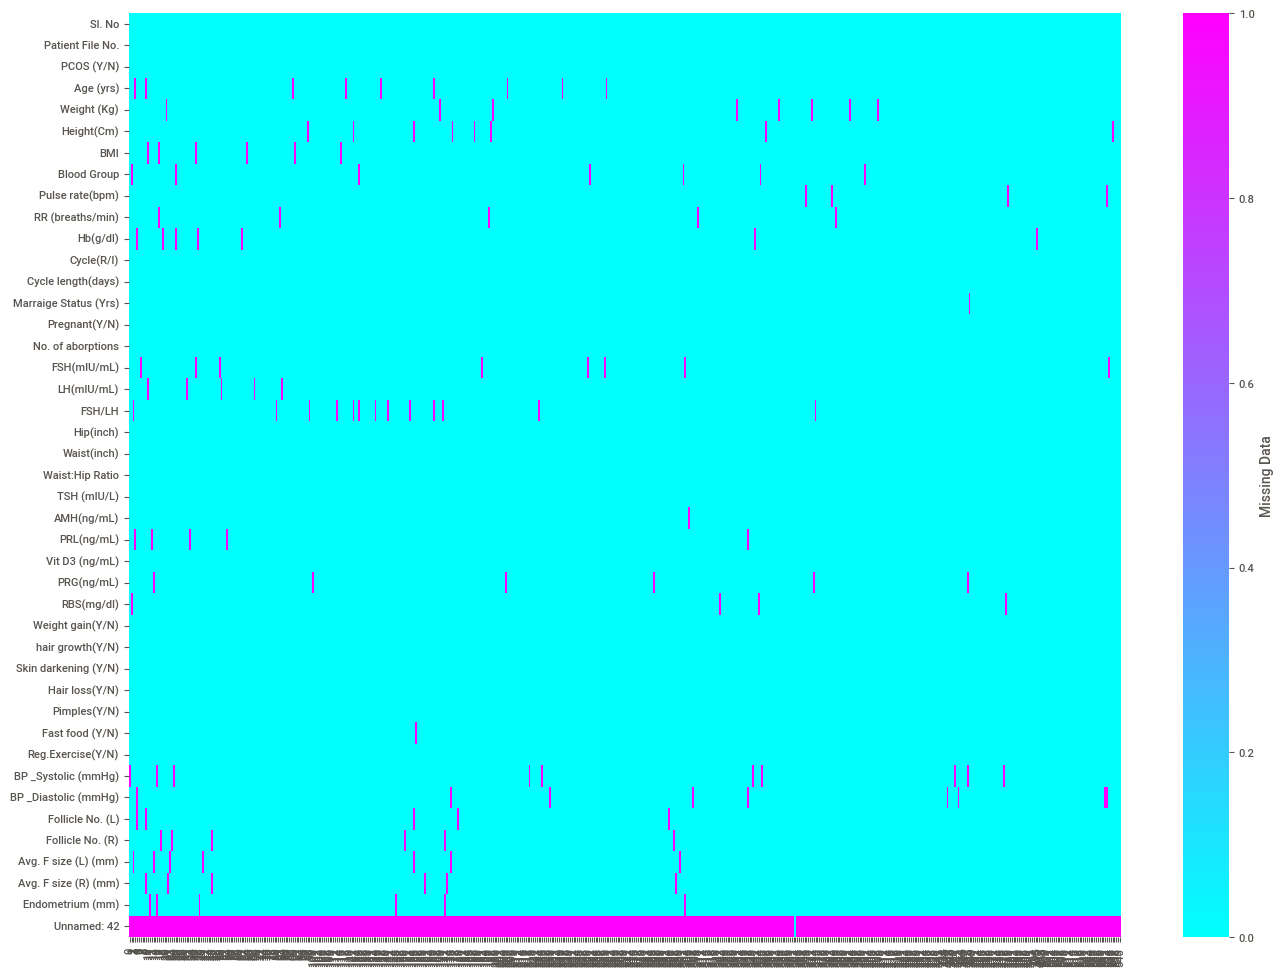

In [ ]:
#plotting heatmap to visualize missing values handling missing values
plt.figure(figsize=(16,12))
sns.heatmap(df.isna().transpose(),
            cmap="cool",
            cbar_kws={'label': 'Missing Data'}, xticklabels=True, yticklabels=True)

In [ ]:
#column names with missing data
lst_missing_columns = df.columns[df.isna().any()].tolist()
lst_missing_columns

['Age (yrs)',
 'Weight (Kg)',
 'Height(Cm)',
 'BMI',
 'Blood Group',
 'Pulse rate(bpm)',
 'RR (breaths/min)',
 'Hb(g/dl)',
 'Marraige Status (Yrs)',
 'FSH(mIU/mL)',
 'LH(mIU/mL)',
 'FSH/LH',
 'AMH(ng/mL)',
 'PRL(ng/mL)',
 'PRG(ng/mL)',
 'RBS(mg/dl)',
 'Fast food (Y/N)',
 'BP _Systolic (mmHg)',
 'BP _Diastolic (mmHg)',
 'Follicle No. (L)',
 'Follicle No. (R)',
 'Avg. F size (L) (mm)',
 'Avg. F size (R) (mm)',
 'Endometrium (mm)',
 'Unnamed: 42']

In [ ]:
for column in df.select_dtypes(include=['float64', 'int64']).columns:
    df[column].fillna(df[column].mean(), inplace=True)# sequential data all misising values replaced with mean

for column in df.select_dtypes(include=['object']).columns:
    df[column].fillna(df[column].mode()[0], inplace=True)# ill in the missing values with mode in categorical data

<ipython-input-102-52a263c431bf>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)# sequential data all misising values replaced with mean


In [ ]:
#Verifying if any missing values are left
df.columns[df.isna().any()].tolist() #no more missing values left

[]

In [ ]:
df = df.replace({'Y': 1, 'N': 0})
df

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 42
0,1,10001,0,28.000000,44.6,152.000000,19.300000,15.000000,78.0,22.0,...,1.0,0,114.655367,80.00000,3.000000,3.0,18.000000,18.0,8.5,7.0
1,2,10002,0,36.000000,65.0,161.500000,24.921163,13.810861,74.0,20.0,...,0.0,0,120.000000,70.00000,3.000000,5.0,15.000000,14.0,3.7,7.0
2,3,10003,1,33.000000,68.8,165.000000,25.270891,11.000000,72.0,18.0,...,1.0,0,120.000000,80.00000,13.000000,15.0,15.003371,20.0,10.0,7.0
3,4,10004,0,31.396617,65.0,148.000000,29.674945,13.000000,72.0,20.0,...,0.0,0,120.000000,70.00000,2.000000,2.0,15.000000,14.0,7.5,7.0
4,5,10005,0,25.000000,52.0,161.000000,20.060954,11.000000,72.0,18.0,...,0.0,0,120.000000,76.87594,6.136194,4.0,16.000000,14.0,7.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,537,10537,0,35.000000,50.0,156.470364,18.500000,17.000000,72.0,16.0,...,0.0,0,110.000000,70.00000,1.000000,0.0,17.500000,10.0,6.7,7.0
537,538,10538,0,30.000000,63.2,158.000000,25.300000,15.000000,72.0,18.0,...,0.0,0,110.000000,70.00000,9.000000,7.0,19.000000,18.0,8.2,7.0
538,539,10539,0,36.000000,54.0,152.000000,23.400000,13.000000,74.0,20.0,...,0.0,0,110.000000,80.00000,1.000000,0.0,18.000000,9.0,7.3,7.0
539,540,10540,0,27.000000,50.0,150.000000,22.200000,15.000000,74.0,20.0,...,0.0,0,110.000000,70.00000,7.000000,6.0,18.000000,16.0,11.5,7.0


In [ ]:

df_numeric = df.select_dtypes(include=['number'])
plt.figure(figsize=(20, 20))
dataplot = sns.heatmap(df_numeric.corr(), cmap="spring", annot=True)
plt.show()


In [ ]:
#Checking how different features are correlated to PCOS
df.corr()["PCOS (Y/N)"].sort_values(ascending=False) #sorting in descending order

In [ ]:
#Identifying numerical and categorical features in dataframe
numerical_variables = []
categorical_variables = []
for x in df.columns:
    if len(df[x].value_counts()) < 9:
        if x not in ["RR (breaths/min)", "Cycle(R/I)", "No. of aborptions", "BP _Systolic (mmHg)", "BP _Diastolic (mmHg)"]:
            categorical_variables.append(x)
    else:
        numerical_variables.append(x)

In [ ]:
categorical_variables

In [ ]:
numerical_variables

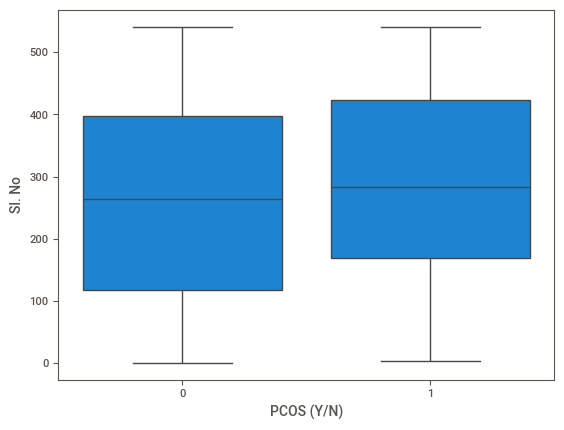

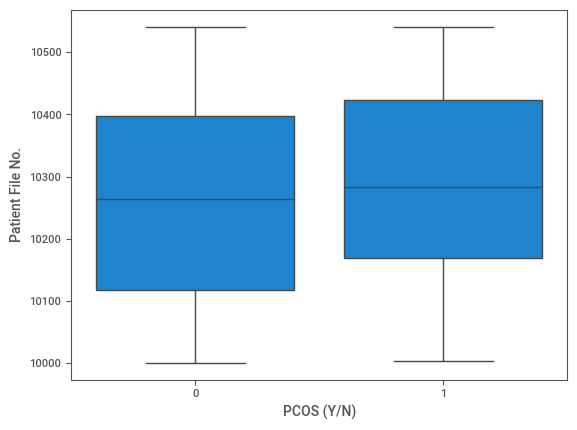

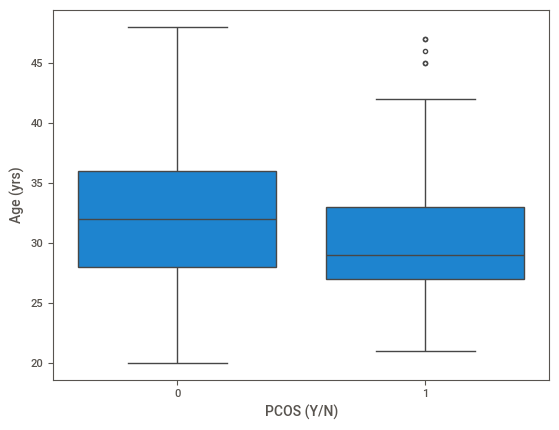

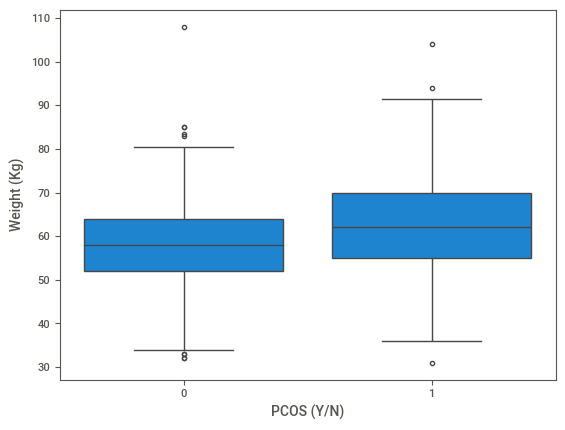

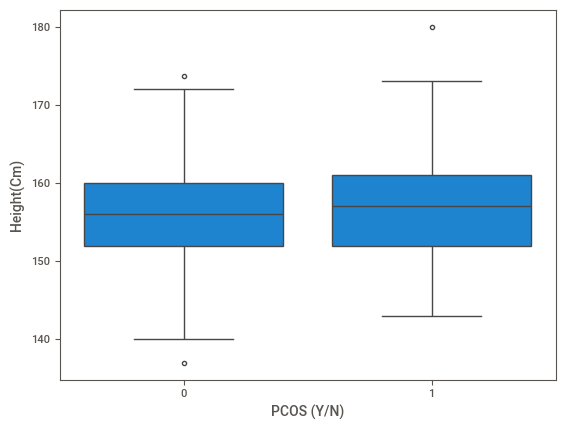

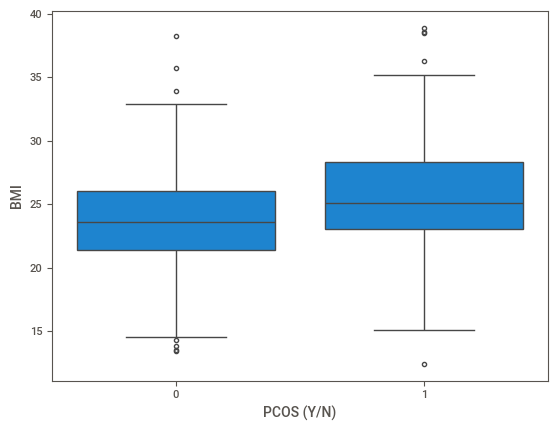

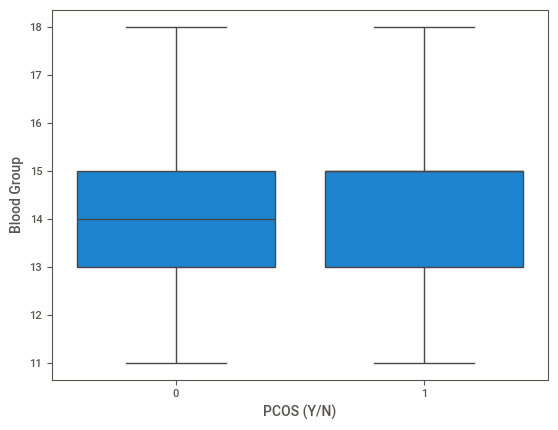

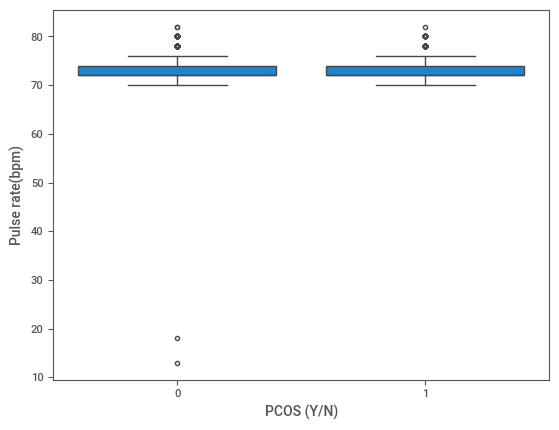

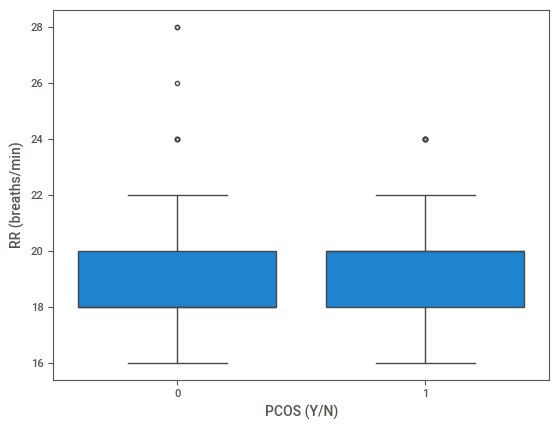

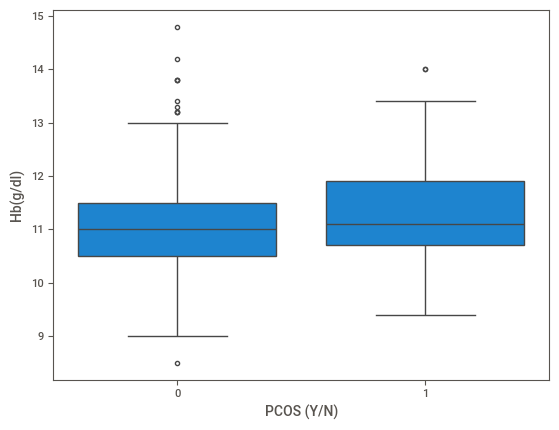

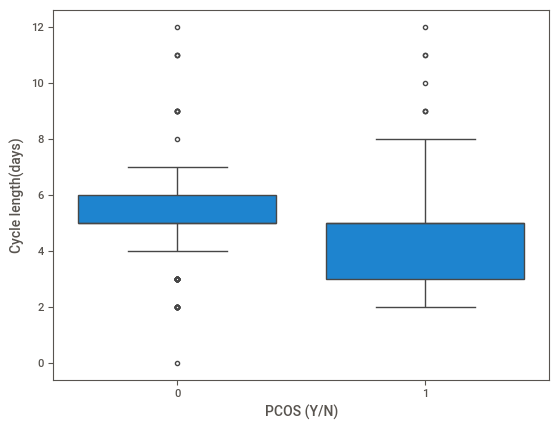

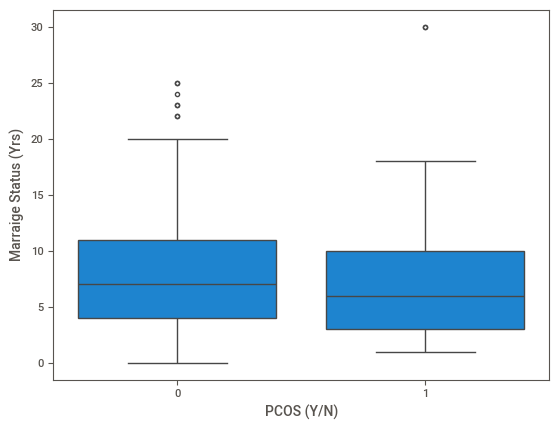

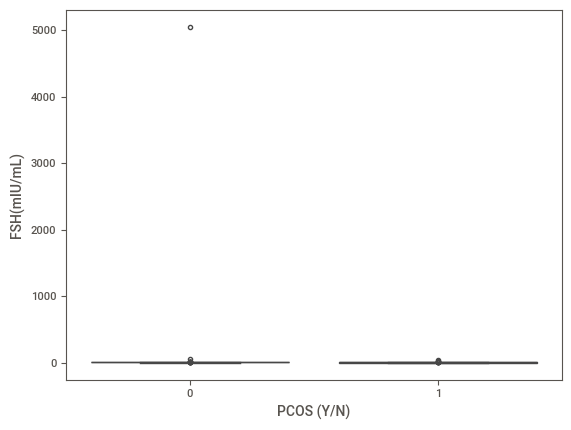

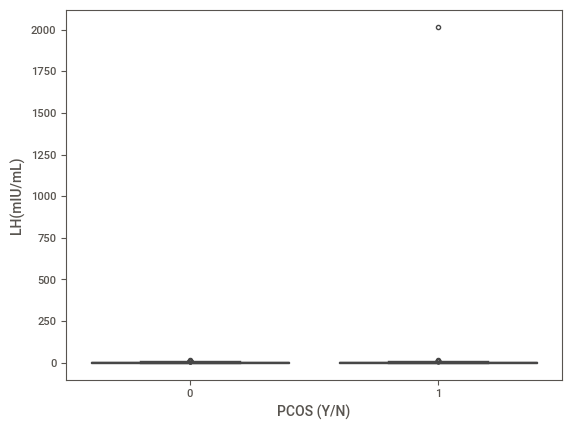

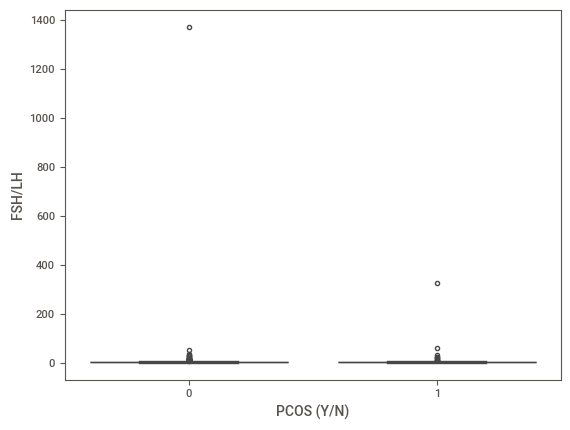

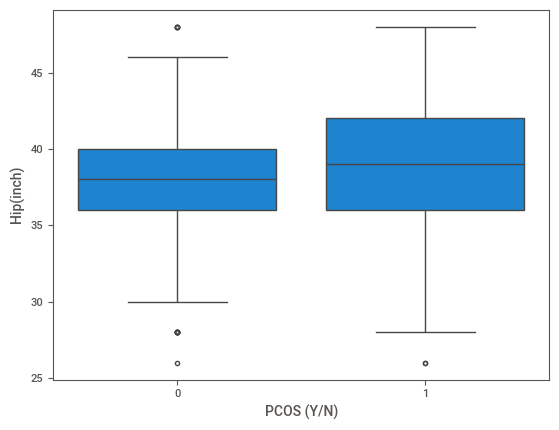

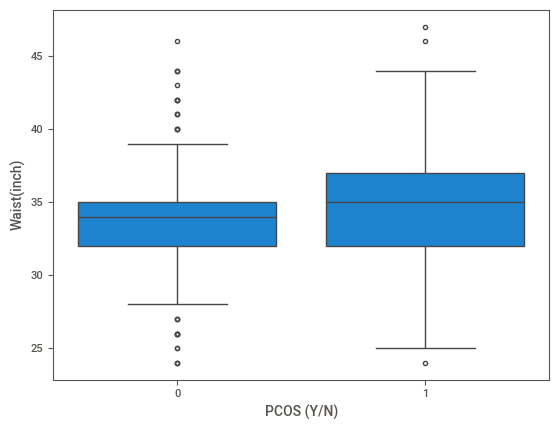

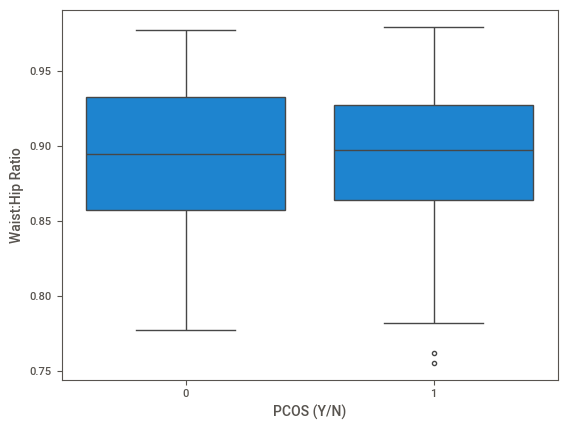

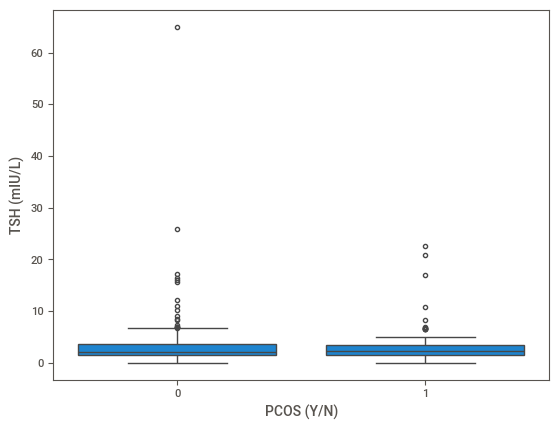

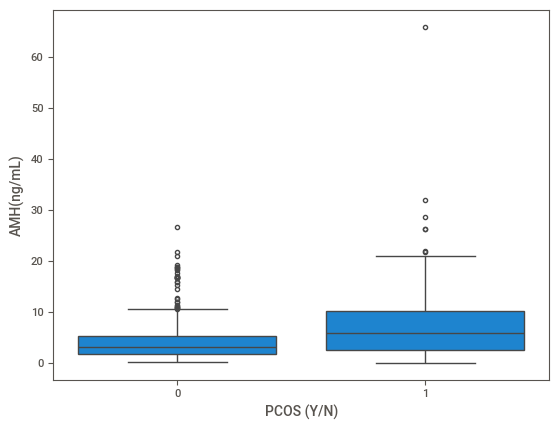

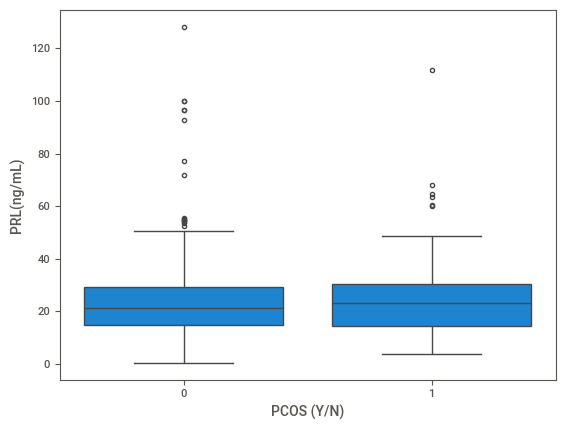

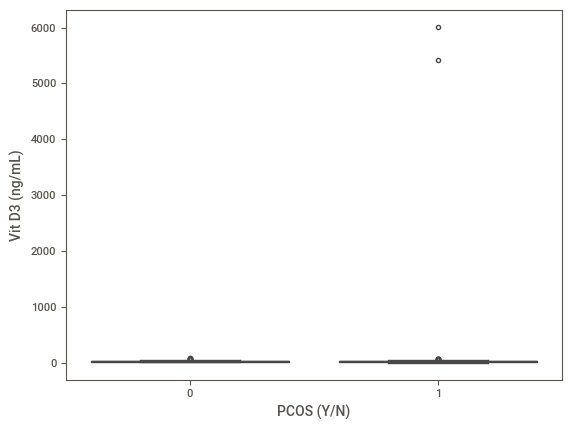

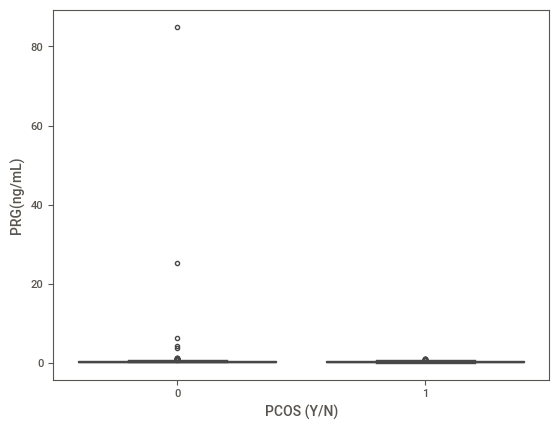

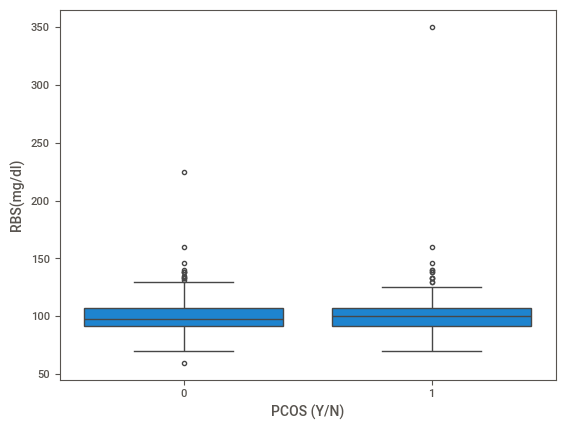

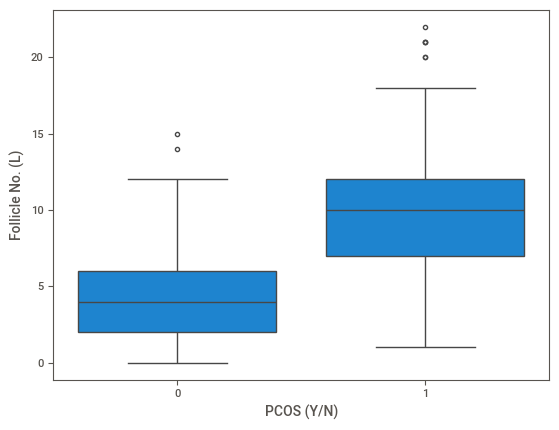

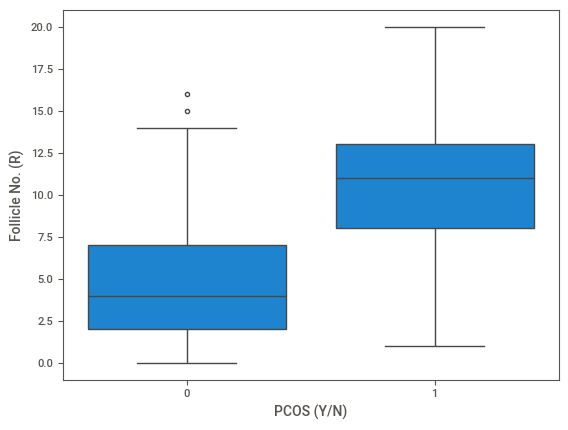

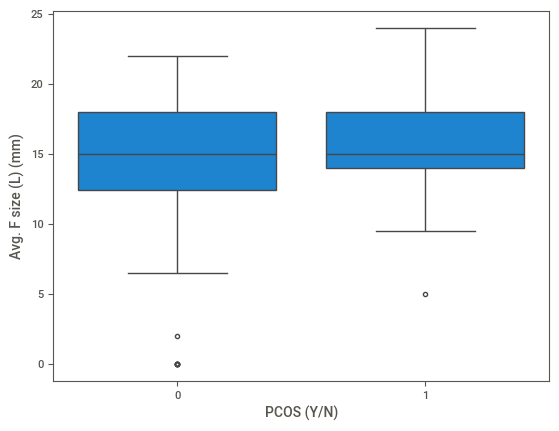

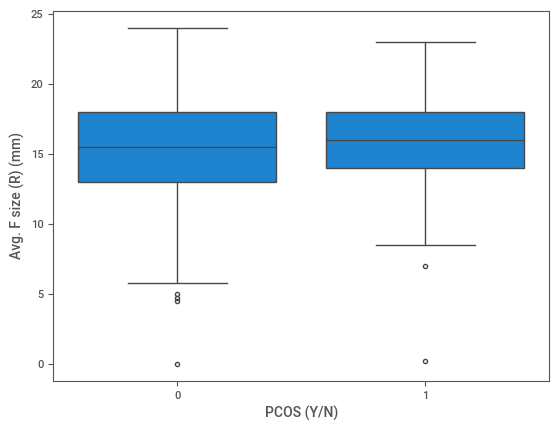

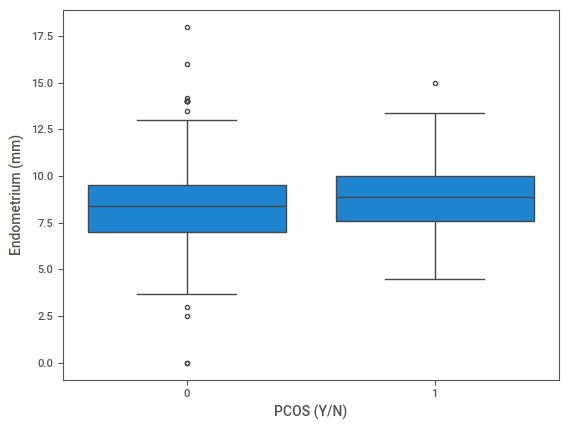

In [ ]:
#Plotting Box plot for the numerical variables
for y in numerical_variables:
    sns.boxplot(y=y, x="PCOS (Y/N)", data=df)
    plt.show()

In [ ]:

corr_matrix = df.corr()
print(corr_matrix)

In [ ]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

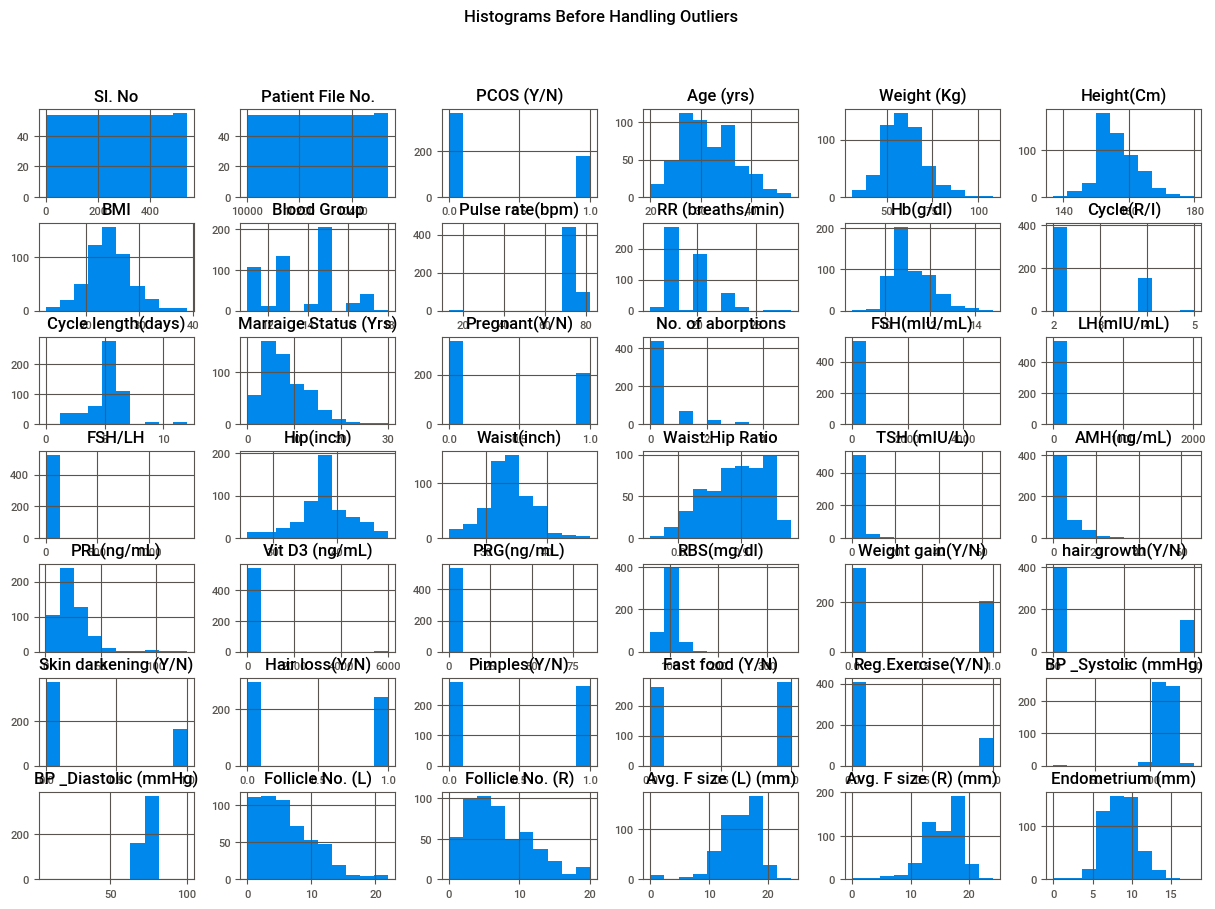

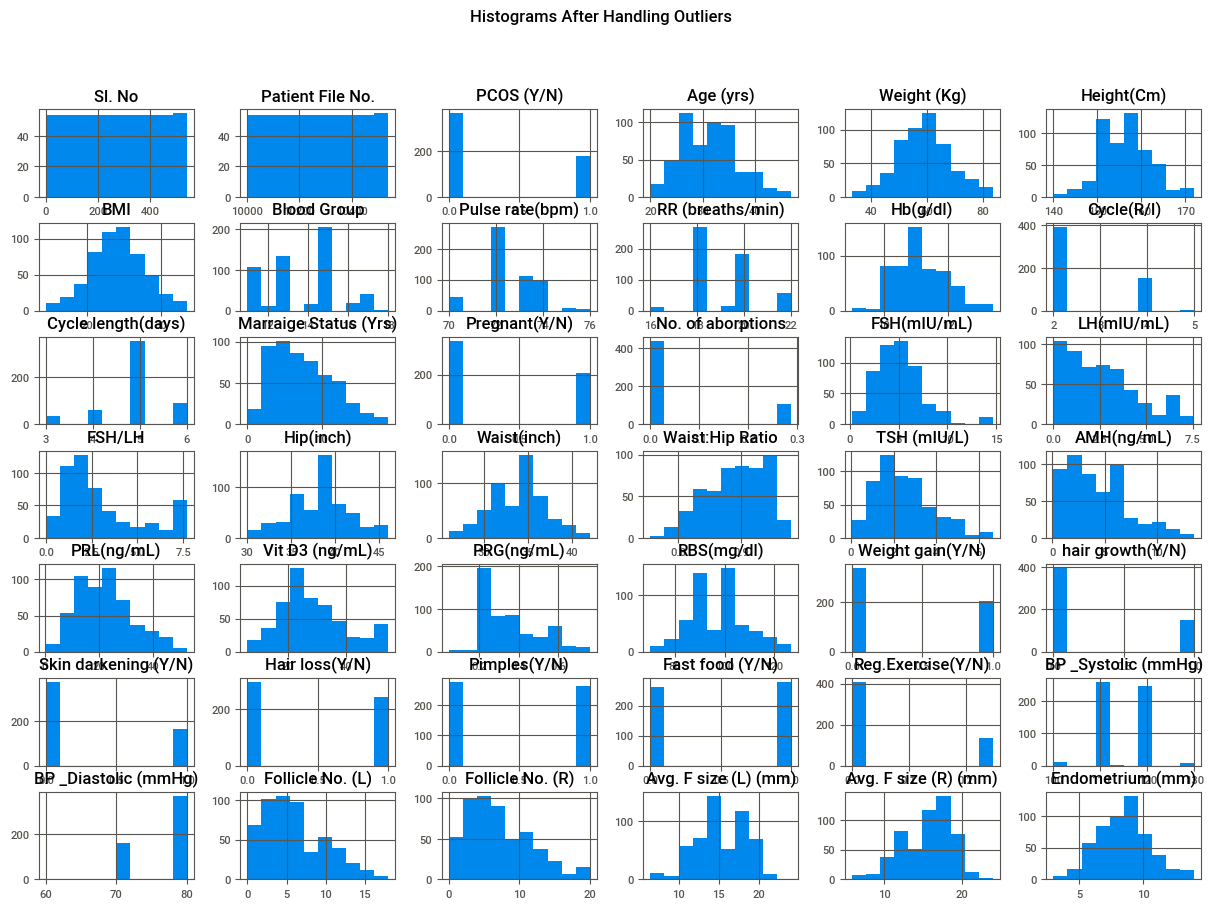

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_histograms(data, title):
    num_cols = [col for col in data.columns if data[col].dtype in ['float64', 'int64']]
    data[num_cols].hist(bins=10, figsize=(15, 10))
    plt.suptitle(title)
    plt.show()
plot_histograms(df, "Histograms Before Handling Outliers")
data = df.copy()
for column in data.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mean_value = data[column].mean()
    data[column] = np.where((data[column] < lower_bound) | (data[column] > upper_bound), mean_value, data[column])
plot_histograms(data, "Histograms After Handling Outliers")


In [ ]:
print("Summary Statistics Before Handling Outliers:")
print(df.describe())

print("\n\n***************************************\n\n")

print("\nSummary Statistics After Handling Outliers:")
print(data.describe())

Summary Statistics Before Handling Outliers:
           Sl. No  Patient File No.  PCOS (Y/N)   Age (yrs)  Weight (Kg)  \
count  541.000000        541.000000  541.000000  532.000000   533.000000   
mean   271.000000      10271.000000    0.327172   31.396617    59.636210   
std    156.317519        156.317519    0.469615    5.422856    11.071284   
min      1.000000      10001.000000    0.000000   20.000000    31.000000   
25%    136.000000      10136.000000    0.000000   27.000000    52.000000   
50%    271.000000      10271.000000    0.000000   31.000000    59.000000   
75%    406.000000      10406.000000    1.000000   35.000000    65.000000   
max    541.000000      10541.000000    1.000000   48.000000   108.000000   

       Height(Cm)         BMI  Blood Group  Pulse rate(bpm)  RR (breaths/min)  \
count  533.000000  535.000000   534.000000       537.000000        536.000000   
mean   156.470364   24.290240    13.810861        73.256983         19.244403   
std      6.064875    4.0586

In [ ]:
'''Observations from boxplot

higher the follicle number more the tendancy of PCOS
patients with lower cycle lengths means more tendancy of PCOS
the average age of patients diagnosed with PCOS is 30 years
#Plotting barplot for categorical variables'''
for x in categorical_variables:
    if x != "PCOS (Y/N)":
        sns.barplot(x= x, y = "PCOS (Y/N)", data = df)
        plt.show()

In [ ]:
# Display summary stats
print(data.describe())
# Count rows above or below 1.5*IQR
for column in data.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    print(f"{column} has {len(outliers)} outliers")


           Sl. No  Patient File No.  PCOS (Y/N)   Age (yrs)  Weight (Kg)  \
count  541.000000        541.000000  541.000000  532.000000   533.000000   
mean   271.000000      10271.000000    0.327172   31.365407    58.931054   
std    156.317519        156.317519    0.469615    5.374685     9.481931   
min      1.000000      10001.000000    0.000000   20.000000    33.000000   
25%    136.000000      10136.000000    0.000000   27.000000    52.000000   
50%    271.000000      10271.000000    0.000000   31.000000    59.636210   
75%    406.000000      10406.000000    1.000000   35.000000    65.000000   
max    541.000000      10541.000000    1.000000   47.000000    83.500000   

       Height(Cm)         BMI  Blood Group  Pulse rate(bpm)  RR (breaths/min)  \
count  533.000000  535.000000   534.000000       537.000000        536.000000   
mean   156.337385   24.183689    13.810861        72.529155         19.101533   
std      5.736981    3.569660     1.836618         1.157517          1.4

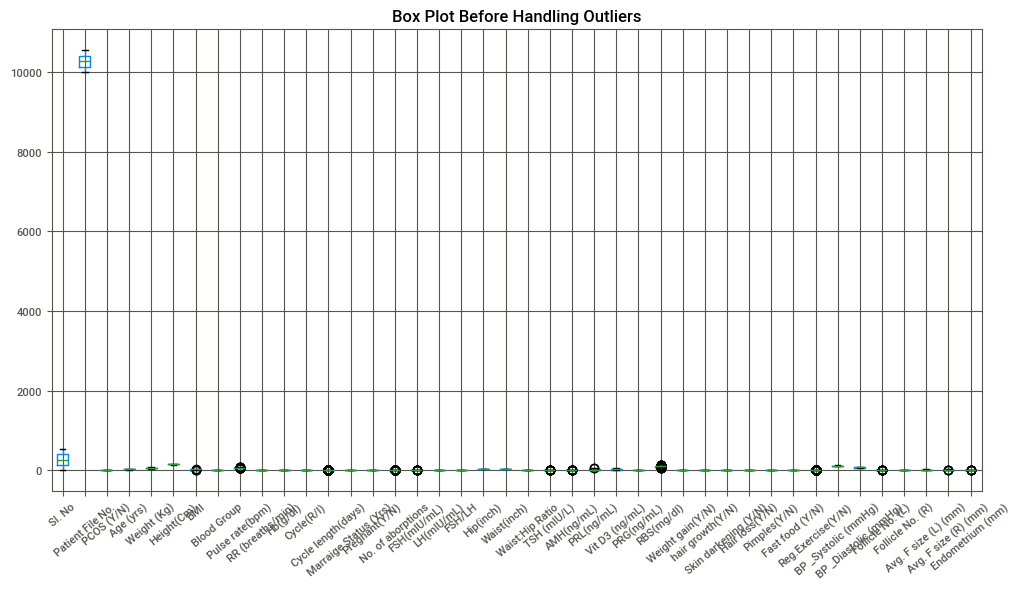

In [ ]:
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(12, 6))
data[num_cols].boxplot()
plt.title("Box Plot Before Handling Outliers")
plt.xticks(rotation=40)
plt.show()

In [ ]:
for column in data.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data[column] = np.clip(data[column], lower_bound, upper_bound)


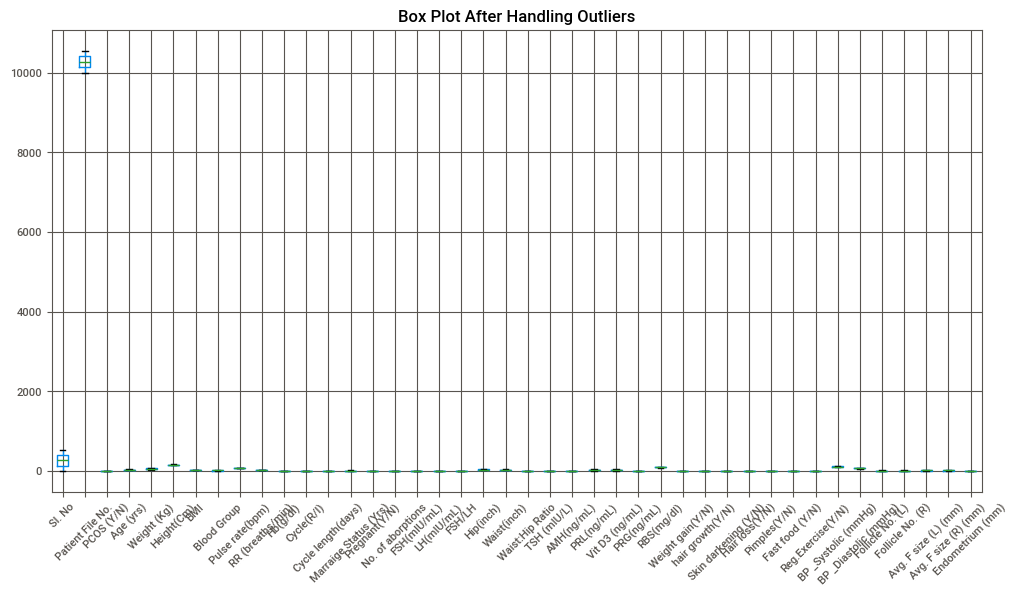

In [ ]:

plt.figure(figsize=(12, 6))
data[num_cols].boxplot()
plt.title("Box Plot After Handling Outliers")
plt.xticks(rotation=45)
plt.show()

In [ ]:
'''Observations from barplot-

weight gain, hair growth, pipmles, hair loss, fast food and skin darkening means higher chances of PCOS.

So the above can also be termed as symptoms of PCOS
'''
sns.countplot(x = "PCOS (Y/N)", data = df)

In [ ]:
df["PCOS (Y/N)"].value_counts()

In [ ]:
177/(364 + 177)*100

In [ ]:
df

In [ ]:
y = df.iloc[:, 0]
X = df.iloc[:, 1:]
y,x

In [ ]:
!pip install sweetviz
import sweetviz as sv

report = sv.analyze(df)
report.show_html("report.html")  # Generates an interactive report

In [ ]:
from google.colab import files
import IPython.display as display

# Path to the saved HTML report
report_path = "/content/report.html"

# Display the HTML report in the notebook
display.display(display.HTML(report_path))

# Optionally, you can also download the report if needed
files.download(report_path)